# Why does the model predict what it predicts?

The frozen model, opened up so anyone can follow why it calls a map the way it does, using
the three tools the Day 6 brief names: feature importance, SHAP values and a
partial-dependence plot. Nothing here changes the model.

It's a logistic regression (a weighted score turned into a probability) with two inputs:

1. **The rating gap:** how much better team A's players had been playing than team B's, over
   maps already played, recent ones counting more. Combat score stands in where rating is
   missing.
2. **Who chose the map:** team A, team B, or nobody (the decider).

Everything below explains the model fitted on all 756 learning maps, the exact one scored on
the test half.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 200)

from dataset import build_map_table, season_folds, split_season
from features import build_features, feature_columns
from form import player_form
from model import FINAL_COLUMNS, evaluate, make_final_model, make_model, picker_baseline

# Red always means "towards team A", blue "towards team B", grey neutral -- the same
# colours as the presentation. Checked with a colour-blindness validator: the red and blue
# stay distinct under all three common kinds of colour blindness.
RED, BLUE, GREY = "#FF4655", "#2E6DB4", "#8A949E"
INK, MUTED, RULE = "#2A3038", "#5A6570", "#D5DAE0"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": RULE, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RULE, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})

INPUTS = ["rating gap", "who picked"]

In [2]:
maps = build_map_table()
learn, _ = split_season(maps)
x_agents, y = build_features(learn, feature_columns(maps))
X = pd.concat([x_agents, player_form(learn, half_life=5)], axis=1)[FINAL_COLUMNS].astype(float)

model = make_final_model().fit(X, y)
fallback, imputer, scaler, lr = (step for _, step in model.steps)

# Confirm this is the frozen model before explaining it.
scores = evaluate(make_final_model(), X, y, learn)
print(f"{len(X)} learning maps")
print(f"five-fold accuracy {scores['accuracy'].mean():.1%}, log loss {scores['log_loss'].mean():.3f}"
      "  -- should match notebook 09")

756 learning maps
five-fold accuracy 61.1%, log loss 0.676  -- should match notebook 09


## 1. The two weights

Each input gets a **weight**: how far it moves the score for team A. The inputs use different
units (a rating gap is a few hundredths; who picked is +1, 0 or −1), so each is first put on a
common scale where 1 means one typical-sized difference.

In [3]:
weights = pd.DataFrame({
    "weight, common scale": lr.coef_[0],
    "one typical difference is": scaler.scale_,
    "weight per raw unit": lr.coef_[0] / scaler.scale_,
}, index=INPUTS)

start = 1 / (1 + np.exp(-lr.intercept_[0]))
print(f"starting point, before either input: {lr.intercept_[0]:+.3f} -> {start:.1%} for team A")
print(f"rating gap does {lr.coef_[0][0] / lr.coef_[0][1]:.1f}x the work of who picked, on the common scale\n")
weights.round(3)

starting point, before either input: +0.012 -> 50.3% for team A
rating gap does 2.0x the work of who picked, on the common scale



,"weight, common scale",one typical difference is,weight per raw unit
rating gap,0.358,0.095,3.753
who picked,0.183,0.911,0.201


**The rating gap carries about twice the weight of who chose the map**, and both point the
right way. **The starting point is 50.3%**: no hidden preference for whichever side is listed
as team A.

## 2. The weights as win chance

The model's win chance for team A across a range of rating gaps (up to one bigger than 90% of
real maps), for each "who picked" answer:

In [4]:
def chance(gap, picked):
    """The model's win chance for team A, given a rating gap and who picked (+1 A, 0 nobody, -1 B)."""
    gap, picked = np.broadcast_arrays(np.asarray(gap, float), np.asarray(picked, float))
    rows = pd.DataFrame({"rating_diff": gap.ravel(), "acs_diff": np.nan,
                         "map_picked_by_a": picked.ravel()})
    return model.predict_proba(rows)[:, 1].reshape(gap.shape)

repaired = fallback.transform(X)["rating_diff"]          # rating gap after the combat-score repair
typical = repaired.abs().quantile([0.25, 0.5, 0.75, 0.9])

gaps = {"0 (evenly matched)": 0.0}
gaps |= {f"{v:.3f}  ({int(q * 100)}th percentile)": v for q, v in typical.items()}
table = pd.DataFrame(
    {label: {"team A chose": chance(g, 1), "nobody chose": chance(g, 0), "team B chose": chance(g, -1)}
     for label, g in gaps.items()}
).T
print("win chance for team A, by the gap in player rating (team A better by...)\n")
print((table.astype(float) * 100).map("{:.1f}%".format).to_string())

pick_worth = chance(0, 1) - chance(0, 0)
gap_equal = weights.loc["who picked", "weight per raw unit"] / weights.loc["rating gap", "weight per raw unit"]
print(f"\nchoosing the map is worth {pick_worth * 100:+.1f} points on an even matchup")
print(f"the same as a rating gap of {gap_equal:.3f}; the median gap between two sides is {typical[0.5]:.3f}")
known = repaired.abs().dropna()
print(f"sides are at least {gap_equal:.3f} apart on {(known >= gap_equal).mean():.0%} of the {len(known)} maps "
      "where the gap is known")

win chance for team A, by the gap in player rating (team A better by...)

                         team A chose nobody chose team B chose
0 (evenly matched)              54.5%        49.5%        44.5%
0.030  (25th percentile)        57.3%        52.3%        47.3%
0.064  (50th percentile)        60.4%        55.5%        50.5%
0.110  (75th percentile)        64.4%        59.7%        54.8%
0.177  (90th percentile)        69.9%        65.6%        60.9%

choosing the map is worth +5.0 points on an even matchup
the same as a rating gap of 0.054; the median gap between two sides is 0.064
sides are at least 0.054 apart on 55% of the 675 maps where the gap is known


**Choosing the map is worth five points of win chance on an even matchup**, the same as a
rating gap of 0.054. The median gap between two sides is 0.064, so on a typical map form
counts slightly more; on a close one, the map choice counts more. (The 81 maps with no
history on a side are left out of those percentiles: that's missing information, not a
measured gap.)

It's a modest model: even a gap bigger than 90% of real ones only takes a map into the
mid-60s.

## 3. The same thing as a picture: partial dependence

One line per "who picked" answer, as the rating gap moves. The lower panel shows where real
maps fall.

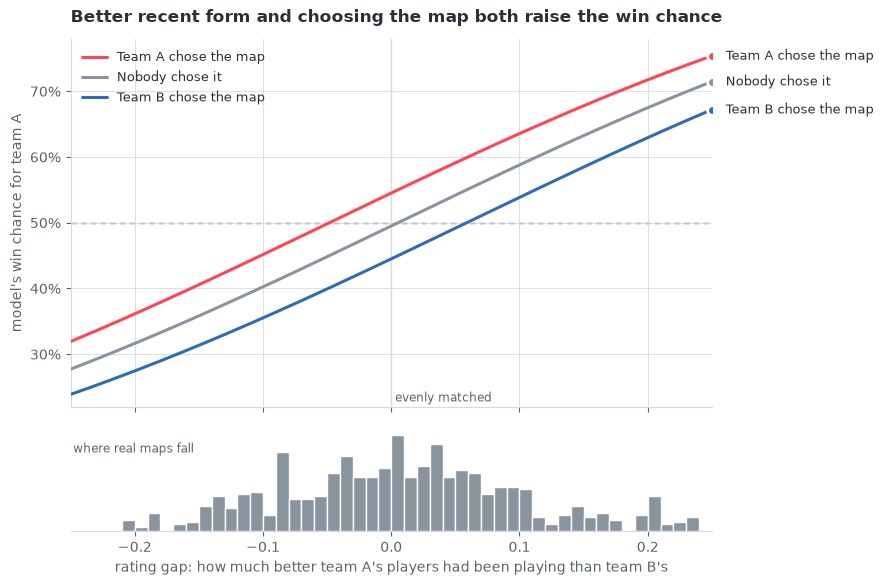

In [5]:
grid = np.linspace(-0.25, 0.25, 201)
fig, (ax, hx) = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                             gridspec_kw={"height_ratios": [4, 1.1], "hspace": 0.1})

ax.axhline(0.5, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
ax.axvline(0, color=RULE, lw=1, zorder=1)
lines = [(1, RED, "Team A chose the map"), (0, GREY, "Nobody chose it"), (-1, BLUE, "Team B chose the map")]
for picked, colour, label in lines:
    ys = chance(grid, picked)
    ax.plot(grid, ys, color=colour, lw=2.2, label=label, zorder=3, solid_capstyle="round")
    ax.plot(grid[-1], ys[-1], "o", ms=7, color=colour, mec="white", mew=2, zorder=4)
    ax.annotate(label, (grid[-1], ys[-1]), xytext=(10, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=INK)

ax.set_ylim(0.22, 0.78)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("model's win chance for team A")
ax.set_title("Better recent form and choosing the map both raise the win chance", loc="left", pad=12)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.text(0.003, 0.228, "evenly matched", color=MUTED, fontsize=8.5)

hx.hist(repaired.dropna(), bins=np.linspace(-0.25, 0.25, 51), color=GREY, edgecolor="white", linewidth=1)
hx.set_yticks([])
hx.grid(False)
hx.spines["left"].set_visible(False)
hx.set_xlabel("rating gap: how much better team A's players had been playing than team B's")
hx.text(-0.248, hx.get_ylim()[1] * 0.78, "where real maps fall", color=MUTED, fontsize=8.5)
hx.set_xlim(-0.25, 0.25)
fig.subplots_adjust(right=0.8)
plt.show()

The lines never cross or flatten: choosing the map is worth the same whatever the rating gap.
That's what a model with no interactions looks like, and it's the right shape here. Notebook 08
gave tree models, which *can* bend, every chance, and they did worse.

## 4. Feature importance: which input does the work?

The fair test is to take an input away, **refit**, and score on the same five folds.
(Scrambling a column shows what a fitted model *leans on*, not what the column adds; notebook
08 shows why that matters.)

In [6]:
baseline = picker_baseline(y, learn)
runs = {
    "both inputs (the final model)": evaluate(make_final_model(), X, y, learn),
    "rating gap only": evaluate(make_final_model(), X.assign(map_picked_by_a=0.0), y, learn),
    "who picked only": evaluate(make_model(LogisticRegression(max_iter=5000)),
                                X[["map_picked_by_a"]], y, learn),
}
importance = pd.DataFrame({
    name: {"accuracy": s["accuracy"].mean(), "log loss": s["log_loss"].mean(),
           "folds beating the picker rule": int((s["accuracy"] > baseline["accuracy"]).sum())}
    for name, s in runs.items()
}).T
importance.loc["the picker rule itself"] = [baseline["accuracy"].mean(), np.nan, np.nan]
print("five folds; 0.693 log loss = saying 50/50 to every map\n")
print(importance.to_string(formatters={"accuracy": "{:.1%}".format, "log loss": "{:.3f}".format,
                                       "folds beating the picker rule": "{:.0f}".format}))

print("\naccuracy on each fold")
print(pd.DataFrame({name: s["accuracy"] for name, s in runs.items()} | {"picker rule": baseline["accuracy"]})
      .map("{:.1%}".format).to_string())

five folds; 0.693 log loss = saying 50/50 to every map

                              accuracy log loss folds beating the picker rule
both inputs (the final model)    61.1%    0.676                             5
rating gap only                  57.7%    0.679                             2
who picked only                  54.4%    0.691                             0
the picker rule itself           55.5%      NaN                           NaN

accuracy on each fold
     both inputs (the final model) rating gap only who picked only picker rule
fold                                                                          
1                            61.0%           57.4%           53.7%       58.8%
2                            60.5%           50.8%           58.9%       58.9%
3                            58.2%           63.1%           50.8%       50.8%
4                            59.5%           58.6%           50.0%       50.0%
5                            66.4%           58.8%       

**Neither input is convincing alone; together they are.** The rating gap alone beats the
picker rule on average but on only two folds of five, and who picked alone *is* the picker
rule's information. Together, the model beats the rule on every fold, because the two inputs
carry different information.

**Are the weights stable?** Refit on each fold's learning part:

In [7]:
stability = {}
for fold, (learn_rows, _) in enumerate(season_folds(learn), start=1):
    fitted = make_final_model().fit(X.loc[learn_rows], y.loc[learn_rows])
    reg = fitted.steps[-1][1]
    stability[f"fold {fold}"] = {"maps learned from": len(learn_rows),
                                 "rating gap": reg.coef_[0][0], "who picked": reg.coef_[0][1]}
stability["all 756 (the final model)"] = {"maps learned from": len(X),
                                          "rating gap": lr.coef_[0][0], "who picked": lr.coef_[0][1]}
stability = pd.DataFrame(stability).T
stability["maps learned from"] = stability["maps learned from"].astype(int)
stability.round(3)

,maps learned from,rating gap,who picked
fold 1,127,0.237,0.195
fold 2,263,0.188,0.237
fold 3,387,0.188,0.231
fold 4,509,0.325,0.179
fold 5,625,0.364,0.147
all 756 (the final model),756,0.358,0.183


**Both weights point the same way on every fold**, even with only 127 maps to learn from.

The rating weight grows through the season, from about 0.2 in the first three folds to 0.36
by the last, while who picked stays between 0.15 and 0.24. One possible reason, not tested:
early in the season everyone's record is short and noisy, and a model trusts a noisy input
less. Testing it would mean slicing the same 629 maps again, so it's left as a hypothesis,
and one more reason more seasons of data would help.

## 5. SHAP values: why *this* map?

A SHAP value says, **for one map, how much each input pushed the prediction and in which
direction**. Add a map's SHAP values to the starting point and you get its prediction exactly.

For a straight-line model, a SHAP value is simply the input's weight times how far that map's
value sits from the average. Below, it's worked out by hand *and* with the `shap` library, in
the model's internal units (log-odds).

In [8]:
# What the regression actually sees: repaired, gap-filled, then put on the common scale.
Z = pd.DataFrame(scaler.transform(imputer.transform(fallback.transform(X))), columns=INPUTS, index=X.index)

by_hand = Z - Z.mean()                  # how far each map sits from the average...
by_hand = by_hand * lr.coef_[0]         # ...times that input's weight

# The library's default takes a random 100 maps as its reference point for "average";
# give it all 756 so it answers exactly the question the hand version answers.
explainer = shap.LinearExplainer(lr, shap.maskers.Independent(Z, max_samples=len(Z)))
from_library = pd.DataFrame(explainer.shap_values(Z), columns=INPUTS, index=X.index)

print(f"largest difference between hand and library, across all {len(Z)} maps x 2 inputs: "
      f"{(by_hand - from_library).abs().to_numpy().max():.1e}")
print(f"library's starting point {float(np.ravel(explainer.expected_value)[0]):+.4f}, "
      f"model's starting point {lr.intercept_[0]:+.4f}")

reach = from_library.abs().mean()
print(f"\naverage size of each input's push on a map (internal units):")
print(reach.round(3).to_string())
print(f"-> on a typical map, the rating gap moves the prediction {reach['rating gap'] / reach['who picked']:.1f}x "
      "as far as who picked")

largest difference between hand and library, across all 756 maps x 2 inputs: 0.0e+00
library's starting point +0.0117, model's starting point +0.0117

average size of each input's push on a map (internal units):
rating gap    0.267
who picked    0.167
-> on a typical map, the rating gap moves the prediction 1.6x as far as who picked


Hand and library agree exactly, on every map.

On an average map the rating gap moves the prediction 1.6 times as far as who picked, less
than the 2x the weights suggest. That's because who picked is almost always at full strength
(+1 or −1), while most rating gaps are small and 81 maps have none.

## 6. Three maps, explained

Chosen by rule, not by hand: its most confident right call, its most confident wrong call,
and a map where the two inputs pulled in opposite directions. They're maps the model learned
from, so they show *how* it reasons, not how accurate it is.

In [9]:
p = pd.Series(model.predict_proba(X)[:, 1], index=X.index)
confidence = (p - 0.5).abs()
right = (p >= 0.5).astype(int) == y
opposed = (np.sign(from_library["rating gap"]) == -np.sign(from_library["who picked"])) & (X["map_picked_by_a"] != 0)

examples = {
    "Most confident correct call": confidence[right].idxmax(),
    "Most confident wrong call": confidence[~right].idxmax(),
    "The two inputs pull opposite ways": confidence[opposed].idxmin(),
}

picked_by = {"team_a": "team A", "team_b": "team B", "decider": "nobody (decider)"}
rows = []
for why, i in examples.items():
    m = learn.loc[i]
    winner = m["team_a"] if m["team_a_won"] else m["team_b"]
    rows.append({"": why, "match": f"{m['team_a']} (A) vs {m['team_b']} (B)", "map": m["map"],
                 "event": m["event"], "chose the map": picked_by[m["map_picked_by"]],
                 "rating gap": round(repaired.loc[i], 3), "model: team A wins": f"{p.loc[i]:.1%}",
                 "result": f"{winner} won {max(m['score_a'], m['score_b'])}-{min(m['score_a'], m['score_b'])}"})
pd.DataFrame(rows).set_index("")

,match,map,event,chose the map,rating gap,model: team A wins,result
,,,,,,,
Most confident correct call,MIBR (A) vs FURIA (B),Icebox,VCT 2025 Americas Stage 1,team A,0.288,78.0%,MIBR won 13-3
Most confident wrong call,TYLOO (A) vs FunPlus Phoenix (B),Icebox,VCT 2025 China Stage 1,team B,-0.274,22.3%,TYLOO won 13-6
The two inputs pull opposite ways,KRÜ Esports (A) vs 2Game Esports (B),Abyss,VCT 2025 Americas Kickoff,team B,0.059,50.0%,KRÜ Esports won 13-3


largest change in a push from reversing the order, across these three maps: 1.4 points


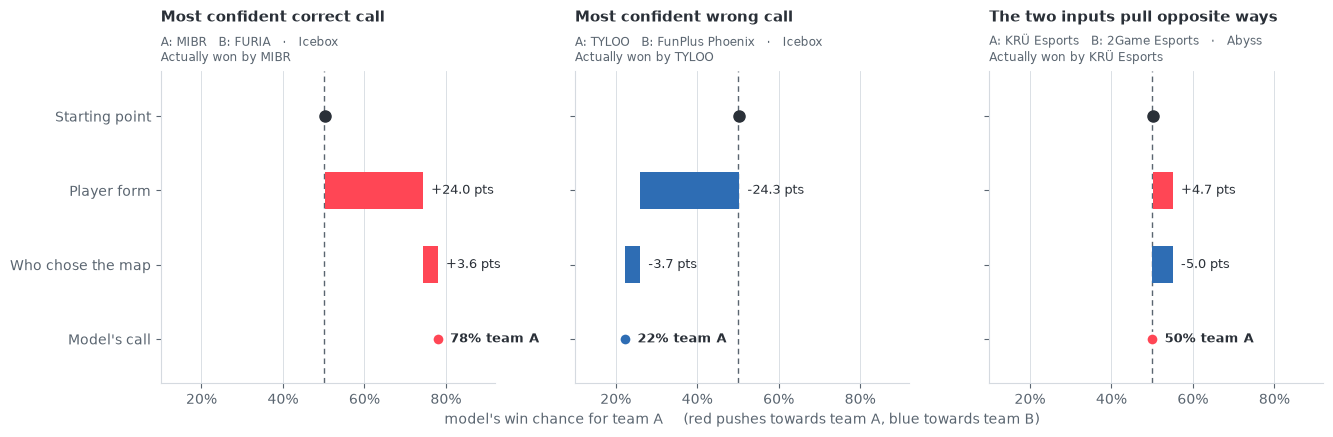

In [10]:
def sigmoid(v):
    return 1 / (1 + np.exp(-v))

start_score = float(np.ravel(explainer.expected_value)[0])
# The percentage-point size of each push depends a little on which is added first. Measure it.
order_effect = max(
    abs((sigmoid(start_score + from_library.loc[i, "rating gap"]) - sigmoid(start_score))
        - (sigmoid(start_score + from_library.loc[i].sum()) - sigmoid(start_score + from_library.loc[i, "who picked"])))
    for i in examples.values())
print(f"largest change in a push from reversing the order, across these three maps: {order_effect * 100:.1f} points")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)
steps = ["Starting point", "Player form", "Who chose the map", "Model's call"]

for ax, (why, i) in zip(axes, examples.items()):
    m = learn.loc[i]
    s_rating, s_pick = from_library.loc[i, "rating gap"], from_library.loc[i, "who picked"]
    levels = [sigmoid(start_score), sigmoid(start_score + s_rating), sigmoid(start_score + s_rating + s_pick)]
    assert abs(levels[-1] - p.loc[i]) < 1e-9, "the pushes must add up to the model's call"

    ax.axvline(0.5, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
    ypos = [3, 2, 1, 0]
    # start and end as markers, the two pushes as floating bars
    ax.plot(levels[0], ypos[0], "o", ms=8, color=INK, zorder=4)
    for k, (lo, hi) in enumerate([(levels[0], levels[1]), (levels[1], levels[2])], start=1):
        colour = RED if hi >= lo else BLUE
        ax.barh(ypos[k], hi - lo, left=lo, height=0.5, color=colour, zorder=3)
        points = (hi - lo) * 100
        ax.annotate(f"{points:+.1f} pts", (max(lo, hi), ypos[k]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9.5, color=INK)
    ax.plot(levels[2], ypos[3], "o", ms=9, color=RED if levels[2] >= 0.5 else BLUE, mec="white", mew=2, zorder=4)
    ax.annotate(f"{levels[2]:.0%} team A", (levels[2], ypos[3]), xytext=(9, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=INK, fontweight="bold")

    winner = m["team_a"] if m["team_a_won"] else m["team_b"]
    ax.set_title(why, loc="left", fontsize=11, pad=36)
    ax.text(0, 1.02, f"A: {m['team_a']}   B: {m['team_b']}   ·   {m['map']}\nActually won by {winner}",
            transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")
    ax.set_yticks(ypos, steps if ax is axes[0] else [""] * 4)
    ax.set_ylim(-0.6, 3.6)
    ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

axes[0].set_xlim(0.1, 0.92)
axes[1].set_xlabel("model's win chance for team A     (red pushes towards team A, blue towards team B)")
fig.subplots_adjust(top=0.76, wspace=0.24)
plt.show()

*Converting internal units to percentage points makes each push depend slightly on the
order they're added (a push is worth a little less near 90% than near 50%). The cell above
measures that for these three maps.*

- **Most confident right call:** both inputs point the same way.
- **Most confident wrong call:** looks exactly the same from the inside. The side in better
  form chose the map, and lost anyway. That's the margin of error, on one map.
- **Inputs disagree:** they cancel, and the model says "about even", which is honest when the
  in-form side is on the other side's map.

## What this notebook found

1. **The model asks two questions: have these players been playing well lately, and who chose
   the map?** Nothing else goes in; agent picks made it worse.
2. **Recent form counts about twice as much as the map choice.**
3. **Choosing the map is worth about five points of win chance**, about the same as the form
   gap between two sides on an ordinary map.
4. **The inputs need each other:** either alone is about as good as a one-sentence rule;
   together they beat it on every fold.
5. **It's modest by design:** it starts every map at 50%, and its confidently wrong calls look
   identical, from the inside, to its confidently right ones.
6. **The shape is simple and stable:** same-direction weights on every fold, lines that never
   cross, and SHAP matching the hand calculation exactly.